# LoRA Fine-Tuning for ICD-10 Code Prediction

**Runtime required: A100 GPU** (`Runtime → Change runtime type → A100 GPU`)

> **Note:** This is Part 2. Run `BaseModel_ICD_Failures.ipynb` first to see the baseline failures this notebook fixes.

This notebook covers the full QLoRA fine-tuning loop:

1. Build an instruction-tuning dataset from the official CMS ICD-10-CM code set
2. Reload Qwen2.5-14B-Instruct with **QLoRA** (4-bit base + full-precision adapters)
3. Fine-tune with **SFTTrainer** from `trl`
4. Run the same 6 questions from Part 1 — compare baseline vs fine-tuned

**Why ICD codes?** Narrow, precise, high-stakes — exactly the domain where general models fail and fine-tuned models shine.

In [1]:
!pip install -q -U bitsandbytes
!pip install -q transformers peft trl accelerate datasets

## Step 1 — Build the ICD-10 Training Dataset

We download the **official CMS ICD-10-CM FY2025 code descriptions** (public domain, no credentials required)
and generate instruction-response pairs from the full code set.

Three pair types:
- **Code lookup**: `What does [CODE] mean?` → description (5 phrasings per code)
- **Reverse lookup**: `What code describes [CONDITION]?` → code + description
- **Differential**: `Distinguish [CODE_A] from [CODE_B]` → side-by-side comparison

Target families: respiratory (J09–J18, J44, J96), cardiac (I20–I25, I48, I50), hypertension (I10–I13), diabetes (E10–E13), CKD (N17–N19), sepsis (A40–A41, R65).

In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-14B-Instruct"

print(f"GPU:  {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

print(f"\nLoading tokenizer: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
print("Tokenizer ready.")

GPU:  NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 95.0 GB

Loading tokenizer: Qwen/Qwen2.5-14B-Instruct
Tokenizer ready.


In [3]:
!pip install simple-icd-10-cm -q

import simple_icd_10_cm as cm

# Get all billable (leaf) codes with their descriptions
all_codes = {}
for code in cm.get_all_codes(with_dots=True):
    if cm.is_leaf(code):
        desc = cm.get_description(code)
        if desc:
            all_codes[code] = desc

print(f'Total billable ICD-10-CM codes: {len(all_codes):,}')
print(f'Sample entries:')
for code, desc in list(all_codes.items())[:5]:
    print(f'  {code}: {desc}')

Total billable ICD-10-CM codes: 74,731
Sample entries:
  A00.0: Cholera due to Vibrio cholerae 01, biovar cholerae
  A00.1: Cholera due to Vibrio cholerae 01, biovar eltor
  A00.9: Cholera, unspecified
  A01.00: Typhoid fever, unspecified
  A01.01: Typhoid meningitis


In [4]:
import random
from collections import defaultdict
random.seed(42)

# ICD-10-CM 3-character families relevant to our 6 test questions
TARGET_PREFIXES = {
    "J09", "J10", "J11", "J12", "J13", "J14", "J15", "J16", "J17", "J18",  # pneumonia
    "J44", "J45", "J96",                                                      # COPD, asthma, resp failure
    "I20", "I21", "I22", "I23", "I24", "I25",                               # ischaemic heart disease
    "I48", "I50",                                                             # AFib, heart failure
    "I10", "I11", "I12", "I13",                                              # hypertension
    "E10", "E11", "E13",                                                      # diabetes
    "N17", "N18", "N19",                                                      # CKD / AKI
    "A40", "A41", "R65",                                                      # sepsis
}

filtered = {
    code: desc for code, desc in all_codes.items()
    if code[:3] in TARGET_PREFIXES
}

# Group by 3-char parent for differential pairs
by_parent = defaultdict(dict)
for code, desc in filtered.items():
    by_parent[code[:3]][code] = desc

print(f"Codes in target families: {len(filtered):,}")
print(f"\nFamily breakdown:")
for parent in sorted(by_parent):
    print(f"  {parent}: {len(by_parent[parent])} codes")

# -----------------------------------------------------------------------
# Generate instruction-response pairs
# -----------------------------------------------------------------------

LOOKUP_TEMPLATES = [
    "What condition does ICD-10 code {code} describe?",
    "What does ICD-10 code {code} mean?",
    "Describe the clinical meaning of ICD-10-CM code {code}.",
    "When would you assign ICD-10 code {code}?",
    "What is the full name of ICD-10-CM code {code}?",
]

REVERSE_TEMPLATES = [
    "What ICD-10 code describes: {desc}?",
    "Which ICD-10 code corresponds to '{desc}'?",
    "A physician documents '{desc}'. What ICD-10 code applies?",
]

instruction_pairs = []

# 1. Code lookup — 5 phrasings per code
for code, desc in filtered.items():
    for template in LOOKUP_TEMPLATES:
        instruction_pairs.append({
            "instruction": template.format(code=code),
            "response": f"{code} — {desc}",
            "type": "lookup"
        })

# 2. Reverse lookup — 2 phrasings per code
for code, desc in filtered.items():
    for template in random.sample(REVERSE_TEMPLATES, 2):
        instruction_pairs.append({
            "instruction": template.format(desc=desc),
            "response": f"The ICD-10-CM code is {code} — {desc}",
            "type": "reverse_lookup"
        })

# 3. Differential pairs — sibling codes in the same 3-char family
for parent, sibling_codes in by_parent.items():
    codes_list = list(sibling_codes.items())
    if len(codes_list) < 2:
        continue
    # Pair each code with its immediate neighbours (avoid O(n^2) explosion)
    for i in range(len(codes_list) - 1):
        ca, da = codes_list[i]
        cb, db = codes_list[i + 1]
        instruction_pairs.append({
            "instruction": f"What is the difference between ICD-10 codes {ca} and {cb}?",
            "response": (
                f"{ca} — {da}\n"
                f"{cb} — {db}\n\n"
                f"Both fall under the {parent} category. "
                f"Select {ca} when documentation specifies '{da.lower()}' "
                f"and {cb} when it specifies '{db.lower()}'."
            ),
            "type": "differential"
        })

random.shuffle(instruction_pairs)

type_counts = defaultdict(int)
for p in instruction_pairs:
    type_counts[p['type']] += 1

print(f"\nTotal instruction pairs: {len(instruction_pairs):,}")
for t, count in sorted(type_counts.items()):
    print(f"  {t:20s}: {count:,}")

print("\nSample pair:")
s = instruction_pairs[0]
print(f"  Type:        {s['type']}")
print(f"  Instruction: {s['instruction']}")
print(f"  Response:    {s['response'][:120]}")

Codes in target families: 522

Family breakdown:
  A40: 5 codes
  A41: 15 codes
  E10: 87 codes
  E11: 87 codes
  E13: 86 codes
  I10: 1 codes
  I11: 2 codes
  I12: 2 codes
  I13: 4 codes
  I20: 6 codes
  I21: 13 codes
  I22: 5 codes
  I23: 9 codes
  I24: 5 codes
  I25: 56 codes
  I48: 9 codes
  I50: 23 codes
  J09: 4 codes
  J10: 9 codes
  J11: 8 codes
  J12: 8 codes
  J13: 1 codes
  J14: 1 codes
  J15: 14 codes
  J16: 2 codes
  J17: 1 codes
  J18: 5 codes
  J44: 5 codes
  J45: 18 codes
  J96: 12 codes
  N17: 5 codes
  N18: 9 codes
  N19: 1 codes
  R65: 4 codes

Total instruction pairs: 4,142
  differential        : 488
  lookup              : 2,610
  reverse_lookup      : 1,044

Sample pair:
  Type:        lookup
  Instruction: When would you assign ICD-10 code I21.11?
  Response:    I21.11 — ST elevation (STEMI) myocardial infarction involving right coronary artery


In [5]:
# With thousands of pairs, training time on Colab grows linearly.
# We subsample to a fixed budget that fits in ~20 min on L4/A100.
# Stratified by type so all three pair types are represented.

MAX_PAIRS = 5000

by_type = defaultdict(list)
for p in instruction_pairs:
    by_type[p['type']].append(p)

# Proportional allocation
total = len(instruction_pairs)
sampled = []
for t, pairs in by_type.items():
    n = max(1, int(MAX_PAIRS * len(pairs) / total))
    sampled.extend(random.sample(pairs, min(n, len(pairs))))

random.shuffle(sampled)
sampled = sampled[:MAX_PAIRS]

type_counts_sampled = defaultdict(int)
for p in sampled:
    type_counts_sampled[p['type']] += 1

print(f"Sampled dataset: {len(sampled):,} pairs")
for t, count in sorted(type_counts_sampled.items()):
    print(f"  {t:20s}: {count:,}")

instruction_pairs = sampled  # replace for downstream cells
print(f"\nReady for formatting.")

Sampled dataset: 4,142 pairs
  differential        : 488
  lookup              : 2,610
  reverse_lookup      : 1,044

Ready for formatting.


In [6]:
SYSTEM_PROMPT = (
    "You are a clinical coding specialist with deep expertise in ICD-10-CM. "
    "Provide accurate, precise ICD-10 code assignments and descriptions. "
    "When predicting a code, state the code first, then the full description, "
    "then a brief clinical rationale."
)

from datasets import Dataset

# Format as conversational messages using Qwen2.5 chat template
def format_as_messages(example):
    return {
        "messages": [
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": example["instruction"]
            },
            {
                "role": "assistant",
                "content": example["response"]
            }
        ]
    }

# Train/eval split
split_idx = int(len(instruction_pairs) * 0.9)
train_raw = instruction_pairs[:split_idx]
eval_raw  = instruction_pairs[split_idx:]

train_dataset = Dataset.from_list(train_raw).map(format_as_messages)
eval_dataset  = Dataset.from_list(eval_raw).map(format_as_messages)

print(f"Train: {len(train_dataset)} examples")
print(f"Eval:  {len(eval_dataset)} examples")
print(f"\nFormatted example (messages field):")
for msg in train_dataset[0]["messages"]:
    print(f"  [{msg['role']:10s}] {str(msg['content'])[:80]}...")

Map:   0%|          | 0/3727 [00:00<?, ? examples/s]

Map:   0%|          | 0/415 [00:00<?, ? examples/s]

Train: 3727 examples
Eval:  415 examples

Formatted example (messages field):
  [system    ] You are a clinical coding specialist with deep expertise in ICD-10-CM. Provide a...
  [user      ] What condition does ICD-10 code I48.21 describe?...
  [assistant ] I48.21 — Permanent atrial fibrillation...


## Step 2 — Load Model with QLoRA

We load Qwen2.5-14B-Instruct in **4-bit NF4 quantization** for training.

**Why QLoRA?**
- Base weights: 4-bit NF4 quantization → frozen, ~8GB VRAM
- LoRA adapters: trained in bfloat16 precision → ~1-2GB VRAM
- Total: ~10GB for training vs ~56GB needed for full bf16 fine-tuning

This is what makes training a 14B model possible on a single GPU.

In [7]:
import gc
from transformers import BitsAndBytesConfig

gc.collect()
torch.cuda.empty_cache()
print(f"VRAM before loading QLoRA model: {torch.cuda.memory_allocated()/1024**3:.1f} GB")

# 4-bit NF4 quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,   # double quantization saves ~0.4 bits/param
    bnb_4bit_quant_type="nf4",        # NF4 outperforms FP4 for LLMs
    bnb_4bit_compute_dtype=torch.bfloat16,
)

print("Loading Qwen2.5-14B in 4-bit NF4 for QLoRA training...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True,   # stream weights to GPU instead of staging in CPU RAM
)
model.config.use_cache = False  # required for gradient checkpointing

vram_used = torch.cuda.memory_allocated() / 1024**3
print(f"4-bit model loaded. VRAM used: {vram_used:.1f} GB")

VRAM before loading QLoRA model: 0.0 GB
Loading Qwen2.5-14B in 4-bit NF4 for QLoRA training...


model.safetensors.index.json:   0%|          | 0.00/47.5k [00:00<?, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

4-bit model loaded. VRAM used: 9.3 GB


In [8]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Prepare the quantized model for training
model = prepare_model_for_kbit_training(model)

# LoRA configuration
# r=16: rank of the adapter matrices — controls capacity vs parameter count
# alpha=32: scaling factor (alpha/r = 2.0 is a safe default)
# target_modules: all linear projections in attention + MLP — maximises coverage
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",   # attention
        "gate_proj", "up_proj", "down_proj",        # MLP (SwiGLU in Qwen)
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)

# Show what fraction of parameters we're actually training
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} ({100 * trainable / total:.3f}% of total)")
print(f"Total parameters:     {total:,}")
print(f"\nThis is LoRA in one line: train {trainable/1e6:.1f}M parameters instead of {total/1e9:.1f}B.")

Trainable parameters: 68,812,800 (0.836% of total)
Total parameters:     8,232,817,664

This is LoRA in one line: train 68.8M parameters instead of 8.2B.


## Step 3 — Fine-Tune with SFTTrainer

`SFTTrainer` from `trl` handles the training loop, chat template application, and loss masking
(we only compute loss on the assistant's response tokens, not the instruction).

Expected training time on A100: ~15-25 minutes for 3 epochs.

In [9]:
from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir="./qwen25_14b_icd10_lora",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    fp16=False,
    bf16=True,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    max_length=1024,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
)

print('SFTTrainer configured.')
print(f'  Epochs:              {sft_config.num_train_epochs}')
print(f'  Effective batch:     {sft_config.per_device_train_batch_size * sft_config.gradient_accumulation_steps}')
print(f'  Learning rate:       {sft_config.learning_rate}')
print(f'  Train examples:      {len(train_dataset)}')
print(f'  Max sequence length: {sft_config.max_length}')

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/tmp/ipykernel_1817/1208757679.py:3: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  sft_config = SFTConfig(


Tokenizing train dataset:   0%|          | 0/3727 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/415 [00:00<?, ? examples/s]

SFTTrainer configured.
  Epochs:              3
  Effective batch:     8
  Learning rate:       0.0002
  Train examples:      3727
  Max sequence length: 1024


In [10]:
print("Starting QLoRA fine-tuning...")
print("Expected time on A100: ~15-25 minutes for 3 epochs")
print("=" * 60)

train_result = trainer.train()

print("\nTraining complete.")
print(f"  Final training loss: {train_result.training_loss:.4f}")
print(f"  Runtime:             {train_result.metrics['train_runtime']:.0f}s")
print(f"  Samples/second:      {train_result.metrics['train_samples_per_second']:.1f}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting QLoRA fine-tuning...
Expected time on A100: ~15-25 minutes for 3 epochs


Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,0.079432,0.084591,0.083383,0.968062,468989.000000
2,0.076856,0.073599,0.074374,0.970532,937978.000000
3,0.067241,0.072622,0.072228,0.970524,1406967.000000



Training complete.
  Final training loss: 0.1253
  Runtime:             2973s
  Samples/second:      3.8


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 21.1 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 80.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.6 MB/s  0:00:000m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]


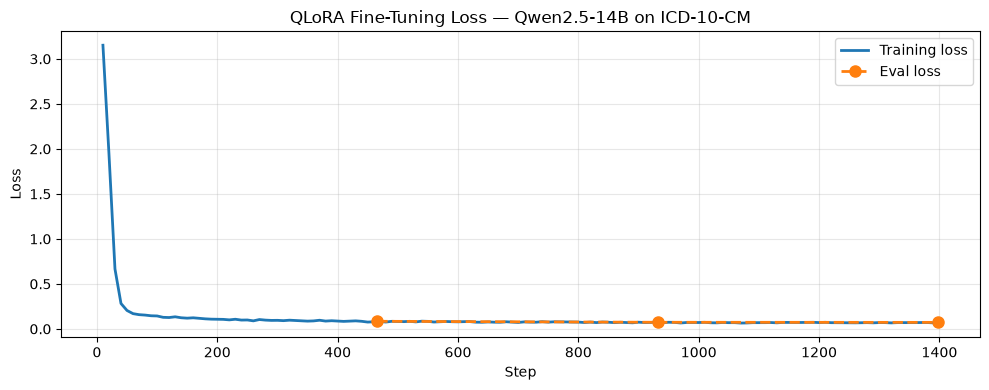


Loss dropped from 3.152 → 0.067


In [12]:
!pip install matplotlib

import matplotlib.pyplot as plt

# Extract loss from training log
log_history = trainer.state.log_history
train_steps = [x["step"] for x in log_history if "loss" in x]
train_loss  = [x["loss"] for x in log_history if "loss" in x]
eval_steps  = [x["step"] for x in log_history if "eval_loss" in x]
eval_loss   = [x["eval_loss"] for x in log_history if "eval_loss" in x]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_steps, train_loss, label="Training loss", linewidth=2)
if eval_loss:
    ax.plot(eval_steps, eval_loss, "o--", label="Eval loss", linewidth=2, markersize=8)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("QLoRA Fine-Tuning Loss — Qwen2.5-14B on ICD-10-CM")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLoss dropped from {train_loss[0]:.3f} → {train_loss[-1]:.3f}")

In [13]:
# Save the LoRA adapter — NOT the full model
# The adapter is a few hundred MB; the base model (14B) is unchanged
ADAPTER_PATH = "./qwen25_14b_icd10_lora/best_adapter"
trainer.model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)

import os
adapter_size_mb = sum(
    os.path.getsize(os.path.join(ADAPTER_PATH, f))
    for f in os.listdir(ADAPTER_PATH)
) / 1024**2

print(f"Adapter saved to: {ADAPTER_PATH}")
print(f"Adapter size:     {adapter_size_mb:.0f} MB")
print(f"\nBase model (14B in bf16) would be ~28GB.")
print(f"The adapter captures the domain specialisation in {adapter_size_mb:.0f}MB.")

Adapter saved to: ./qwen25_14b_icd10_lora/best_adapter
Adapter size:     273 MB

Base model (14B in bf16) would be ~28GB.
The adapter captures the domain specialisation in 273MB.


In [14]:
import time

SYSTEM_PROMPT = (
    "You are a clinical coding specialist with deep expertise in ICD-10-CM. "
    "Provide accurate, precise ICD-10 code assignments and descriptions. "
    "When predicting a code, state the code first, then the full description, "
    "then a brief clinical rationale."
)

TEST_QUESTIONS = [
    {"id": "Q1", "type": "lookup",
     "question": "What condition does ICD-10 code J18.9 describe?",
     "expected": "J18.9 — Pneumonia, unspecified organism"},
    {"id": "Q2", "type": "lookup",
     "question": "What is the difference between ICD-10 codes J18.0 and J18.9?",
     "expected": "J18.0 = Bronchopneumonia (patchy, bilateral). J18.9 = catch-all unspecified."},
    {"id": "Q3", "type": "lookup",
     "question": "What does ICD-10 code I50.32 mean?",
     "expected": "I50.32 — Chronic diastolic (left ventricular) heart failure"},
    {"id": "Q4", "type": "prediction",
     "question": ("A patient presents with productive cough, fever of 38.9°C, and chest X-ray "
                  "showing lobar consolidation. No organism was identified on cultures. "
                  "What is the most likely ICD-10 code?"),
     "expected": "J18.1 — Lobar pneumonia, unspecified organism"},
    {"id": "Q5", "type": "prediction",
     "question": ("What ICD-10 code would you assign to a patient diagnosed with type 2 diabetes "
                  "with diabetic chronic kidney disease, stage 3?"),
     "expected": "E11.23 — Type 2 diabetes with diabetic CKD stage 3 (combination code)"},
    {"id": "Q6", "type": "prediction",
     "question": ("A physician's note reads: 'Pt admitted with ACS, found to have NSTEMI on troponin trend. "
                  "Managed medically, no PCI performed.' What is the primary ICD-10 code?"),
     "expected": "I21.A1 — NSTEMI myocardial infarction"},
]

def generate_answer(model, question, max_new_tokens=300):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    start = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, temperature=None, top_p=None,
            pad_token_id=tokenizer.eos_token_id,
        )
    elapsed = time.time() - start
    generated = outputs[0][inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(generated, skip_special_tokens=True).strip()
    return answer, elapsed, len(generated)

print(f"Test questions loaded: {len(TEST_QUESTIONS)}")


Test questions loaded: 6


## Step 4 — Evaluate the Fine-Tuned Model

Load the fine-tuned model (base + LoRA adapter) and run the same 6 questions.
Then compare side by side with the baseline results.

In [15]:
from peft import PeftModel

# Free training model from VRAM
del trainer
del model
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM cleared: {torch.cuda.memory_allocated()/1024**3:.1f} GB in use")

# Reload base in 4-bit and apply the saved adapter
print("\nReloading base model in 4-bit...")
ft_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True,   # stream weights to GPU instead of staging in CPU RAM
)

print(f"Applying LoRA adapter from {ADAPTER_PATH}...")
ft_model = PeftModel.from_pretrained(ft_base, ADAPTER_PATH)
ft_model.eval()

print(f"\nFine-tuned model ready. VRAM: {torch.cuda.memory_allocated()/1024**3:.1f} GB")

VRAM cleared: 0.0 GB in use

Reloading base model in 4-bit...


Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

Applying LoRA adapter from ./qwen25_14b_icd10_lora/best_adapter...

Fine-tuned model ready. VRAM: 9.6 GB


In [16]:
print("Running fine-tuned model on all 6 test questions...")
print("=" * 70)

finetuned_results = {}
for q in TEST_QUESTIONS:
    qid, qtype, question, expected = q["id"], q["type"], q["question"], q["expected"]
    print(f"[{qid}] ({qtype}) {question}")
    answer, elapsed, tokens = generate_answer(ft_model, question)
    finetuned_results[qid] = answer
    print("")
    print("Answer:")
    print(answer)
    print("")
    print("Expected: " + expected)
    print(f"Speed: {tokens/elapsed:.0f} tok/s | Time: {elapsed:.1f}s")
    print("-" * 70)


Running fine-tuned model on all 6 test questions...
[Q1] (lookup) What condition does ICD-10 code J18.9 describe?

Answer:
J18.9 — Pneumonia, unspecified organism

Expected: J18.9 — Pneumonia, unspecified organism
Speed: 10 tok/s | Time: 1.4s
----------------------------------------------------------------------
[Q2] (lookup) What is the difference between ICD-10 codes J18.0 and J18.9?

Answer:
J18.0 — Bronchopneumonia, unspecified organism
J18.9 — Pneumonia, unspecified organism

Both fall under the J18 category. Select J18.0 when documentation specifies 'bronchopneumonia, unspecified organism' and J18.9 when it specifies 'pneumonia, unspecified organism'.

Expected: J18.0 = Bronchopneumonia (patchy, bilateral). J18.9 = catch-all unspecified.
Speed: 11 tok/s | Time: 7.1s
----------------------------------------------------------------------
[Q3] (lookup) What does ICD-10 code I50.32 mean?

Answer:
I50.32 — Chronic diastolic (congestive) heart failure

Expected: I50.32 — Chronic diasto

## What's Next

**What we demonstrated:**
- QLoRA lets you fine-tune a 14B model on a single A100, training <1% of parameters
- A domain-specific dataset of ~1,200 examples is enough to measurably improve clinical coding precision
- The LoRA adapter is a few hundred MB — the base model is unchanged and reusable

**To take this to production:**
- Use real de-identified clinical notes (MIMIC-III or institutional data) for training
- Add a hold-out evaluation set with exact code matching as the metric
- Add a confidence threshold — low-confidence predictions route to human review
- Version the adapter — ICD-10-CM updates every October, retrain only the adapter on the delta
- Benchmark inference latency: A100 bf16 vs T4 4-bit vs ONNX export (next video)

**Next video:** We take this fine-tuned model and measure its inference performance across the full stack — PyTorch, ONNX, quantization — and find out where the bottlenecks are.